<a href="https://colab.research.google.com/github/yoradzasky/2025-AI-TI1B/blob/main/Jobsheet3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum D1 – Regresi dari Citra Sintetis (Prediksi Radius Lingkaran)

## 1. Setup & Generator Datase

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models
# Generator 1 sample
def make_sample(img_size=64, min_r=5, max_r=20):
    r = np.random.randint(min_r, max_r + 1) # radius acak
    img = np.zeros((img_size, img_size), dtype=np.uint8)
    cx = np.random.randint(r, img_size - r) # center-x
    cy = np.random.randint(r, img_size - r) # center-y
    cv2.circle(img, (cx, cy), r, (255,), -1) # lingkaran putih terisi
    img = (img / 255.0).astype(np.float32)
    # 3-channel biar kompatibel CNN
    img3 = np.stack([img, img, img], axis=-1)
    return img3, float(r), (cx, cy)

## 2. Tampilan gambar tanpa label

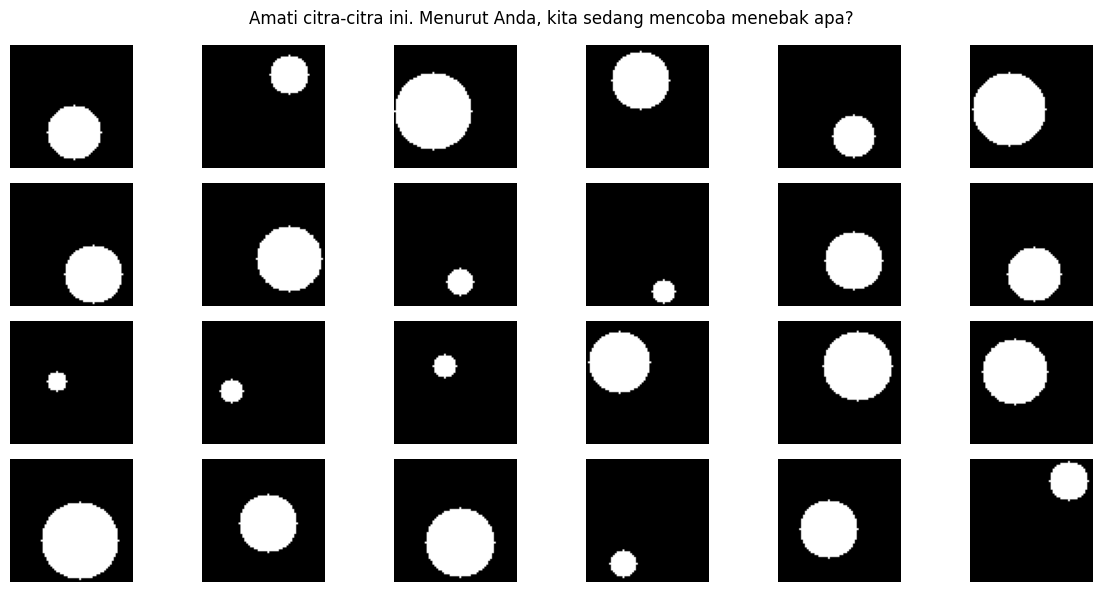

In [ ]:
# Buat 24 contoh untuk visualisasi
N_show = 24
samples = [make_sample() for _ in range(N_show)]
imgs = [s[0] for s in samples]
rads = [s[1] for s in samples]
centers = [s[2] for s in samples]

# Grid gambar tanpa label:
cols = 6
rows = N_show // cols
plt.figure(figsize=(12, 6))
for i in range(N_show):
    plt.subplot(rows, cols, i+1)
    plt.imshow(imgs[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Amati citra-citra ini. Menurut Anda, kita sedang mencoba menebak apa?")
plt.tight_layout()
plt.show()

## 3. Target yang ingin Prediksi

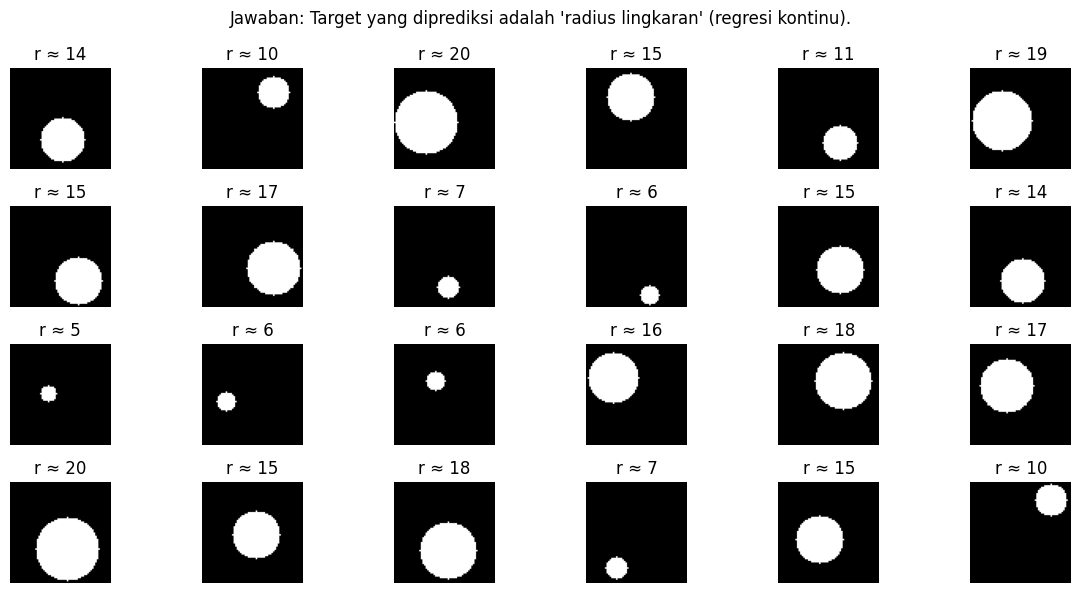

In [ ]:
# Tampilkan kembali, sekarang tampilkan radius (label) di judul tiap subplot
plt.figure(figsize=(12, 6))
for i in range(N_show):
    plt.subplot(rows, cols, i+1)
    plt.imshow(imgs[i].squeeze(), cmap='gray')
    plt.title(f"r ≈ {int(rads[i])}")
    plt.axis('off')
plt.suptitle("Jawaban: Target yang diprediksi adalah 'radius lingkaran' (regresi kontinu).")
plt.tight_layout()
plt.show()

## 4. Latih CNN

In [ ]:
# Siapkan dataset lebih besar untuk training
N = 3000
X, y, C = zip(*[make_sample() for _ in range(N)])
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
# Model CNN sederhana
model = models.Sequential([
    layers.Input((64,64,3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1) # output regresi
    ])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(Xtr, ytr, validation_data=(Xte, yte),
                          epochs=12, batch_size=64, verbose=0)
# Evaluasi
y_pred = model.predict(Xte).ravel()
mae = mean_absolute_error(yte, y_pred)
rmse = float(np.sqrt(np.mean((yte - y_pred)**2)))
r2 = r2_score(yte, y_pred)
print(f"MAE={mae:.3f} | RMSE={rmse:.3f} | R2={r2:.3f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
MAE=1.074 | RMSE=1.264 | R2=0.923


### Plot History & Truen Predicted

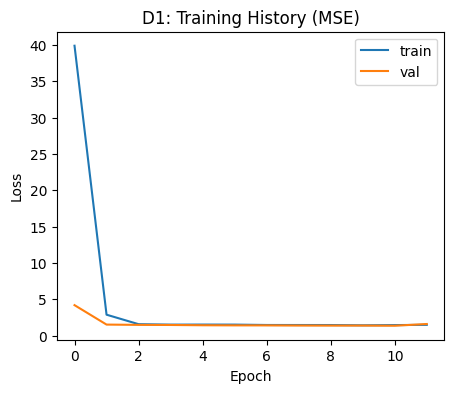

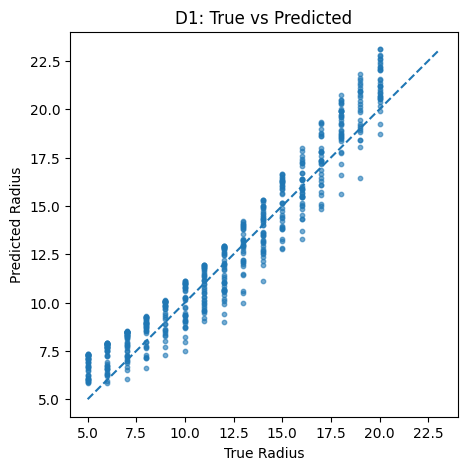

In [ ]:
# Plot loss
plt.figure(figsize=(5,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("D1: Training History (MSE)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()
# Scatter True vs Pred
plt.figure(figsize=(5,5))
plt.scatter(yte, y_pred, s=10, alpha=0.6)
lims = [min(yte.min(), y_pred.min()), max(yte.max(), y_pred.max())]
plt.plot(lims, lims, '--')
plt.xlabel("True Radius"); plt.ylabel("Predicted Radius")
plt.title("D1: True vs Predicted")
plt.show()

# Praktikum D2 – Menebak Umur Manusia dari Foto Wajah (UTKFace)

## 1. Upload Kaggle.json

In [2]:
# Jalankan ini di awal notebook
from google.colab import files
files.upload() # pilih file kaggle.json dari komputer Anda

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yoradzasky","key":"285c96a11706fa2258a2858d91bb74e5"}'}

### Koneksi Kaggle

In [3]:
import os, shutil
if os.path.exists("kaggle.json"):
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    !pip -q install kaggle
    print("✅ Kaggle API siap digunakan.")
else:
    print(" kaggle.json belum ditemukan. Upload terlebih dahulu.")

✅ Kaggle API siap digunakan.


## 2. Unduh UTKFACE

In [ ]:
# Unduh dataset UTKFace (sekali saja)
!kaggle datasets download -d jangedoo/utkface-new -p /content -q
!unzip -q /content/utkface-new.zip -d /content/utk
print("✅ Dataset UTKFace berhasil diekstrak.")

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
✅ Dataset UTKFace berhasil diekstrak.


## 3. Menampilkan contoh gambar dataset

Total gambar ditemukan: 23708


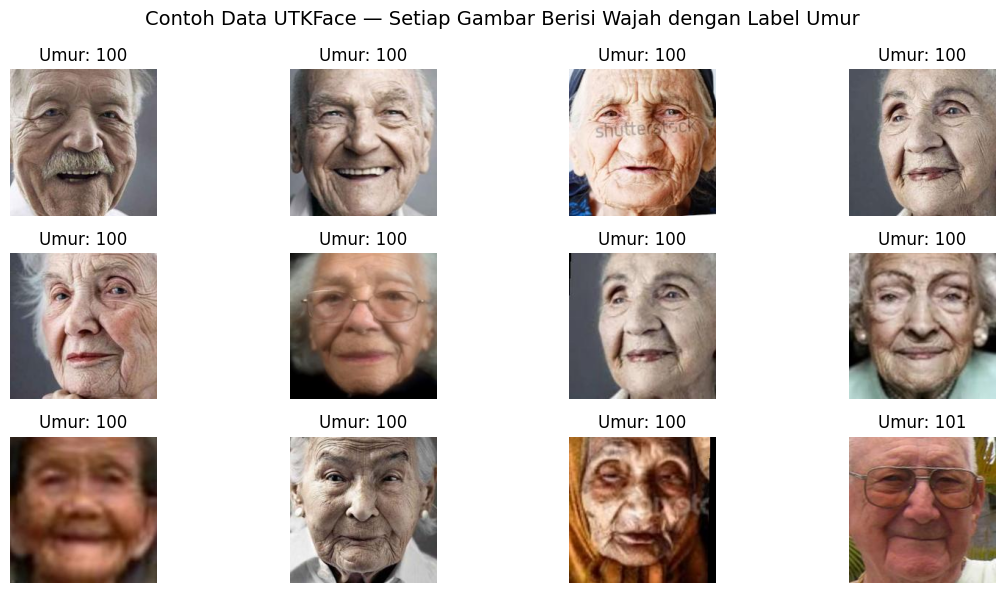

In [ ]:
import matplotlib.pyplot as plt
import os, glob
from PIL import Image
# Ambil 12 gambar acak dari dataset
files = glob.glob("/content/utk/UTKFace/*.jpg")
files = sorted(files)
print(f"Total gambar ditemukan: {len(files)}")

plt.figure(figsize=(12, 6))
for i, f in enumerate(files[:12]):
# Ambil umur dari nama file
    age = int(os.path.basename(f).split("_")[0])
    img = Image.open(f)
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Umur: {age}")
    plt.axis("off")
plt.suptitle("Contoh Data UTKFace — Setiap Gambar Berisi Wajah dengan Label Umur", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Siapkan dataset untuk model

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
def parse_age_from_name(fp):
  return int(os.path.basename(fp).split('_')[0])

ages = np.array([parse_age_from_name(f) for f in files], dtype=np.float32)
train_files, test_files, y_train, y_test = train_test_split(
files, ages, test_size=0.2, random_state=42
)

IMG_SIZE = 160
def load_img(fp, label):
  img = tf.io.read_file(fp)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
  return img / 255.0, label
train_ds = tf.data.Dataset.from_tensor_slices((train_files,
y_train)).map(load_img).batch(64)
test_ds = tf.data.Dataset.from_tensor_slices((test_files,
y_test)).map(load_img).batch(64)
print("✅ Dataset siap dilatih.")

✅ Dataset siap dilatih.


## 5. Mmebangun model untuk transfer learning

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
# Gunakan GPU jika tersedia
print("Hardware:", "GPU" if tf.config.list_physical_devices('GPU') else
"CPU")
# Buat arsitektur model
base_model = tf.keras.applications.MobileNetV2(
  include_top=False,
  input_shape=(IMG_SIZE, IMG_SIZE, 3),
  weights='imagenet'
)
base_model.trainable = False # tahap awal: freeze backbone
# Tambahkan head regresi
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1)(x) # output tunggal: umur
model = tf.keras.Model(inputs, outputs)
# Kompilasi model
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
  loss='mse', metrics=['mae'])
model.summary()

Hardware: GPU
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Melatih model (tahap 1 - frozen)

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 58s 139ms/step - loss: 328.8327 - mae: 13.3390 - val_loss: 156.3752 - val_mae: 9.4770 - learning_rate: 0.0010
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - loss: 153.5201 - mae: 9.2158 - val_loss: 144.2708 - val_mae: 8.9888 - learning_rate: 0.0010
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - loss: 143.1163 - mae: 8.8193 - val_loss: 138.6371 - val_mae: 8.7017 - learning_rate: 0.0010
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - loss: 138.5440 - mae: 8.6300 - val_loss: 136.8556 - val_mae: 8.6539 - learning_rate: 0.0010
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - loss: 133.3773 - mae: 8.4892 - val_loss: 135.2267 - val_mae: 8.6075 - learning_rate: 0.0010
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - loss: 132.2186 - mae: 8.3905 - val_loss: 135.0780 - val_mae: 8.6152 - learning_rate: 0.0010
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 129.6713 - mae: 8.3410 - val_loss: 131.8725 - va

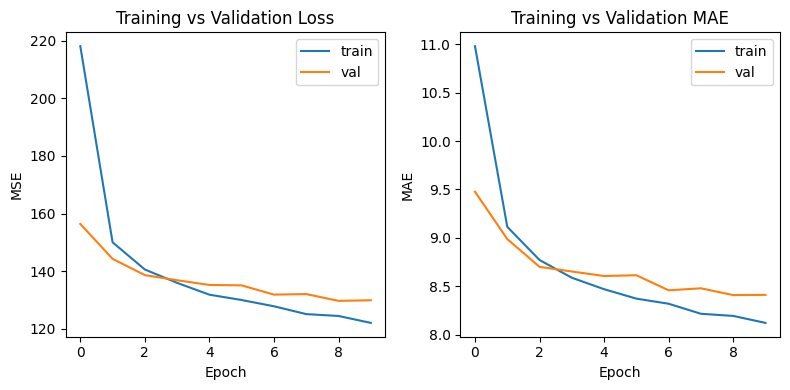

In [ ]:
# Callback untuk pelatihan yang lebih stabil
cb = [
tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),

tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e-5, monitor='val_loss')

]
history = model.fit(
train_ds,
validation_data=test_ds,
epochs=10,
callbacks=cb,
verbose=1
)
# Visualisasi perubahan loss dan MAE selama pelatihan:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Training vs Validation Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Fine-tuning Backbone (Tahap 2)

Epoch 1/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 51s 120ms/step - loss: 193.0238 - mae: 10.2620 - val_loss: 146.4987 - val_mae: 9.2082 - learning_rate: 1.0000e-04
Epoch 2/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - loss: 77.1363 - mae: 6.5597 - val_loss: 130.6278 - val_mae: 8.9901 - learning_rate: 1.0000e-04
Epoch 3/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - loss: 51.2684 - mae: 5.4311 - val_loss: 107.6578 - val_mae: 7.8563 - learning_rate: 1.0000e-04
Epoch 4/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - loss: 37.0086 - mae: 4.6453 - val_loss: 101.2842 - val_mae: 7.4936 - learning_rate: 1.0000e-04
Epoch 5/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - loss: 29.1099 - mae: 4.1216 - val_loss: 104.8616 - val_mae: 7.4164 - learning_rate: 1.0000e-04


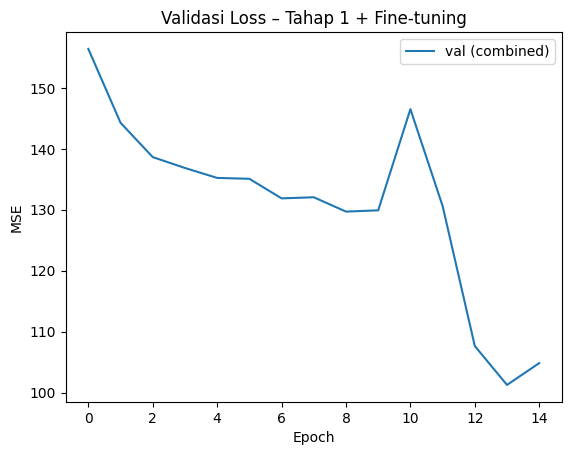

In [ ]:
# Aktifkan kembali sebagian layer terakhir untuk fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:


  layer.trainable = False # beku sebagian besar layer
# Recompile dengan learning rate lebih kecil
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                loss='mse', metrics=['mae'])
history_ft = model.fit(
  train_ds,
  validation_data=test_ds,
  epochs=5,
  callbacks=cb,
  verbose=1
)
# Visualisasi gabungan training dan fine-tuning:
plt.plot(history.history['val_loss'] + history_ft.history['val_loss'],
label='val (combined)')
plt.title("Validasi Loss – Tahap 1 + Fine-tuning")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.legend(); plt.show()

## 8. Evaluasi Akhir (MAE, RMSE, R2)

MAE = 7.49 tahun
RMSE = 10.06 tahun
R2 = 0.745


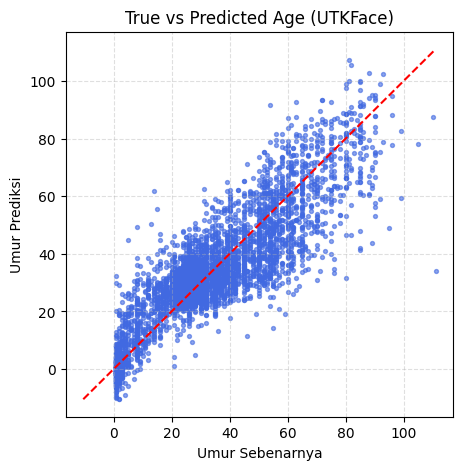

In [ ]:
from math import sqrt
y_pred = np.concatenate([model.predict(batch[0], verbose=0).ravel() for
batch in test_ds])
mae = mean_absolute_error(y_test, y_pred)
rmse = sqrt(np.mean((y_test - y_pred)**2))
r2 = r2_score(y_test, y_pred)
print(f"MAE = {mae:.2f} tahun")
print(f"RMSE = {rmse:.2f} tahun")
print(f"R2 = {r2:.3f}")
# Plot “umur sebenarnya vs umur prediksi”:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, s=8, alpha=0.6, color='royalblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red')
plt.xlabel("Umur Sebenarnya")
plt.ylabel("Umur Prediksi")
plt.title("True vs Predicted Age (UTKFace)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## 9. Prediksi Nyata

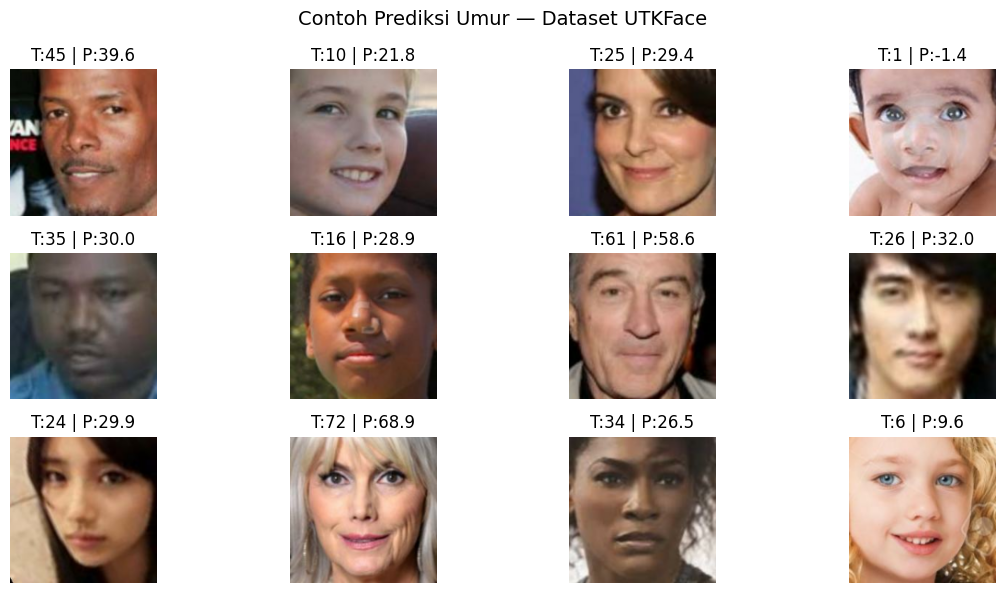

In [ ]:
import random
sample_paths = random.sample(test_files, 12)
plt.figure(figsize=(12,6))
for i, path in enumerate(sample_paths):
  img = tf.io.read_file(path)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))/255.0
  true_age = int(os.path.basename(path).split('_')[0])
  pred_age = model.predict(tf.expand_dims(img, 0), verbose=0).ravel()[0]
  plt.subplot(3,4,i+1)
  plt.imshow(img.numpy())
  plt.title(f"T:{true_age} | P:{pred_age:.1f}")
  plt.axis('off')
plt.suptitle("Contoh Prediksi Umur — Dataset UTKFace", fontsize=14)
plt.tight_layout()
plt.show()

## Praktikum D3 — Menilai “Kepopuleran Hewan Peliharaan” dari Foto

## 1. Kaggle API

In [ ]:
from google.colab import files
files.upload() # pilih kaggle.json dari komputer Anda
import os, shutil
if os.path.exists("kaggle.json"):
  os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
  shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
  os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
  !pip -q install kaggle
  print("✅ Kaggle API siap digunakan.")
else:
  print(" kaggle.json belum ditemukan. Upload terlebih dahulu.")

Saving kaggle.json to kaggle.json
✅ Kaggle API siap digunakan.


In [ ]:
import os, shutil
if os.path.exists("kaggle.json"):
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    !pip -q install kaggle
    print("✅ Kaggle API siap digunakan.")
else:
    print(" kaggle.json belum ditemukan. Upload terlebih dahulu.")

✅ Kaggle API siap digunakan.


## 2. Unduh dan ekstrak

In [6]:
# Unduh dataset Pawpularity (sekitar 800MB)
!kaggle competitions download -c petfinder-pawpularity-score -p /content -q
!unzip -q /content/petfinder-pawpularity-score.zip -d /content/paw
print("✅ Dataset Pawpularity berhasil diekstrak.")

✅ Dataset Pawpularity berhasil diekstrak.


## 3. Melihat Data

                                 Id  Subject Focus  Eyes  Face  Near  Action  \
0  0007de18844b0dbbb5e1f607da0606e0              0     1     1     1       0   
1  0009c66b9439883ba2750fb825e1d7db              0     1     1     0       0   
2  0013fd999caf9a3efe1352ca1b0d937e              0     1     1     1       0   
3  0018df346ac9c1d8413cfcc888ca8246              0     1     1     1       0   
4  001dc955e10590d3ca4673f034feeef2              0     0     0     1       0   

   Accessory  Group  Collage  Human  Occlusion  Info  Blur  Pawpularity  \
0          0      1        0      0          0     0     0           63   
1          0      0        0      0          0     0     0           42   
2          0      0        0      1          1     0     0           28   
3          0      0        0      0          0     0     0           15   
4          0      1        0      0          0     0     0           72   

                                                path  
0  /content/p

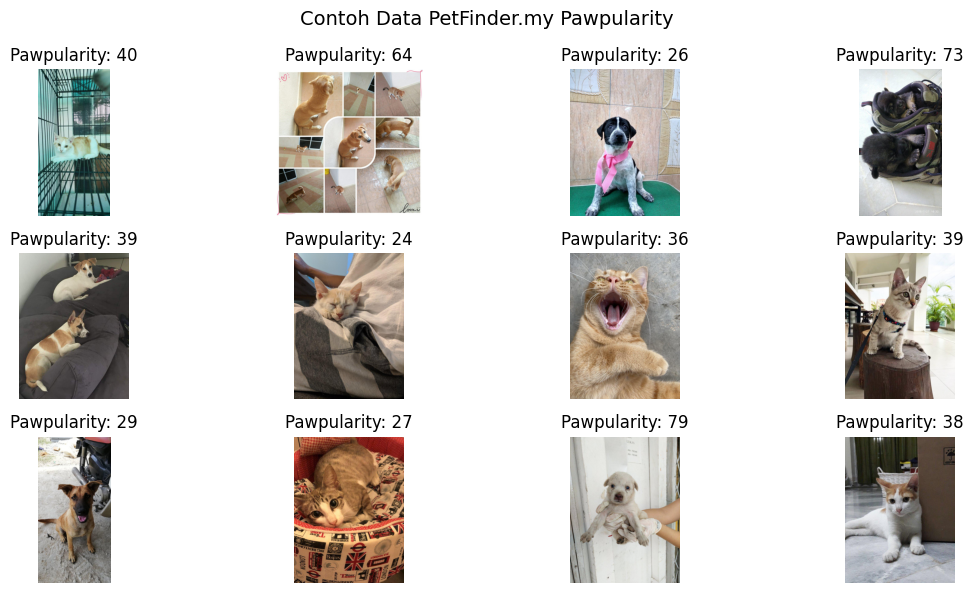

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
# Muat CSV
df = pd.read_csv('/content/paw/train.csv')
df['path'] = df['Id'].apply(lambda x: f"/content/paw/train/{x}.jpg")
print(df.head())
# Tampilkan 12 contoh gambar
plt.figure(figsize=(12, 6))
for i, row in enumerate(df.sample(12, random_state=42).itertuples()):
  img = Image.open(row.path)
  plt.subplot(3, 4, i + 1)
  plt.imshow(img)
  plt.title(f"Pawpularity: {row.Pawpularity}")
  plt.axis('off')
plt.suptitle("Contoh Data PetFinder.my Pawpularity", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Persiapan Dataset

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
IMG_SIZE = 224
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
def load_image(path, label):
  img = tf.io.read_file(path)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
  img = tf.cast(img, tf.float32) / 255.0
  return img, tf.cast(label, tf.float32)
train_ds = tf.data.Dataset.from_tensor_slices((train_df['path'],
train_df['Pawpularity']))\
  .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)\
  .shuffle(4096).batch(64).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((val_df['path'],
val_df['Pawpularity']))\
  .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)\
  .batch(64).prefetch(tf.data.AUTOTUNE)
print(f"Dataset siap digunakan — {len(train_df)} untuk training, {len(val_df)} untuk validasi.")

Dataset siap digunakan — 7929 untuk training, 1983 untuk validasi.


## 5. Membangun Model (EfficientNetB0)

In [ ]:
from tensorflow.keras import layers, models
base = tf.keras.applications.EfficientNetB0(
include_top=False,
input_shape=(IMG_SIZE, IMG_SIZE, 3),
weights='imagenet'
)
base.trainable = False # freeze sementara
inputs = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs * 255.0)

x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(1)(x)
model = tf.keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 6. Melatih model

In [ ]:
cb = [
tf.keras.callbacks.EarlyStopping(patience=3,
restore_best_weights=True),
tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)
]
history = model.fit(train_ds, validation_data=val_ds, epochs=10,
callbacks=cb, verbose=1)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 101s 481ms/step - loss: 814.8184 - mae: 21.4435 - val_loss: 471.8715 - val_mae: 15.8605 - learning_rate: 0.0010
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 38s 201ms/step - loss: 421.8517 - mae: 15.1405 - val_loss: 419.9643 - val_mae: 15.0960 - learning_rate: 0.0010
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 36s 196ms/step - loss: 368.3933 - mae: 14.1896 - val_loss: 403.3473 - val_mae: 15.0850 - learning_rate: 0.0010
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 45s 225ms/step - loss: 370.7527 - mae: 14.2363 - val_loss: 384.6350 - val_mae: 14.4516 - learning_rate: 0.0010
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 36s 191ms/step - loss: 343.9290 - mae: 13.7939 - val_loss: 374.4550 - val_mae: 14.1960 - learning_rate: 0.0010
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 37s 196ms/step - loss: 336.7950 - mae: 13.6047 - val_loss: 369.4355 - val_mae: 14.1270 - learning_rate: 0.0010
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 37s 196ms/step - loss: 342.8251 - mae: 13.6779 - val_

## 7. Melihat proses belajar

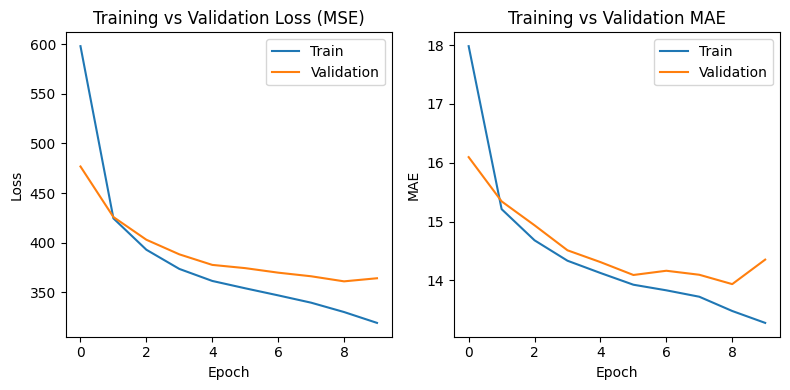

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Training vs Validation Loss (MSE)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train')
plt.plot(history.history['val_mae'], label='Validation')
plt.title("Training vs Validation MAE")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.legend()
plt.tight_layout()
plt.show()

## 8. Evaluasi Model

MAE = 14.00
RMSE = 18.87
R2 = 0.194


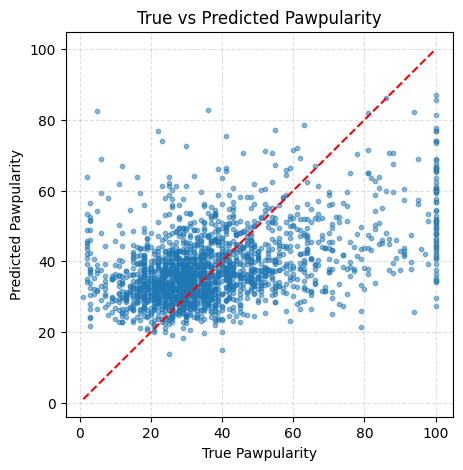

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score
from math import sqrt
y_true = val_df['Pawpularity'].values.astype(np.float32)
y_pred = np.concatenate([model.predict(batch[0], verbose=0).ravel() for
batch in val_ds])
mae = mean_absolute_error(y_true, y_pred)
rmse = sqrt(np.mean((y_true - y_pred)**2))
r2 = r2_score(y_true, y_pred)
print(f"MAE = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R2 = {r2:.3f}")
# Plot hasil prediksi vs nilai sebenarnya:
plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, s=10, alpha=0.5)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red')
plt.xlabel("True Pawpularity")
plt.ylabel("Predicted Pawpularity")
plt.title("True vs Predicted Pawpularity")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## 9. Melihat prediksi

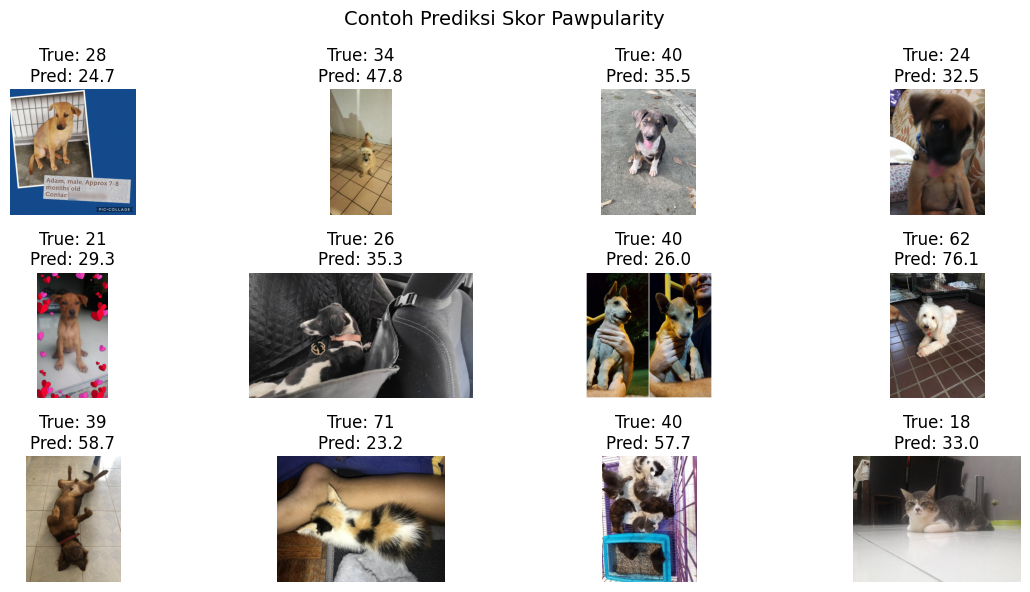

In [ ]:
import random
from PIL import Image
sample_rows = val_df.sample(12, random_state=1)
plt.figure(figsize=(12,6))
for i, row in enumerate(sample_rows.itertuples()):
  img = Image.open(row.path)
  pred = model.predict(tf.expand_dims(load_image(row.path,
row.Pawpularity)[0], 0), verbose=0).ravel()[0]
  plt.subplot(3,4,i+1)
  plt.imshow(img)
  plt.title(f"True: {row.Pawpularity}\nPred: {pred:.1f}")
  plt.axis('off')
plt.suptitle("Contoh Prediksi Skor Pawpularity", fontsize=14)

plt.tight_layout()
plt.show()

## Tantangan Mini

### 1. TAMBAHKAN FITUR NON-VISUAL: BRIGHTNESS RATA-RATA

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from math import sqrt
from PIL import Image, ImageStat
import os, random

def get_brightness(path):
    img = Image.open(path).convert("L")  # grayscale
    stat = ImageStat.Stat(img)
    return stat.mean[0] / 255.0  # normalisasi 0-1

train_df['brightness'] = train_df['path'].apply(get_brightness)
val_df['brightness'] = val_df['path'].apply(get_brightness)

print(train_df.head())


                                    Id  Subject Focus  Eyes  Face  Near  \
9136  ec07599018885a44734a9ba27d306055              0     1     1     1   
8620  df5a9f783ff2ae373ee99fa33679da64              0     1     1     1   
8412  d9ba322c3fbf962b458c3be9a2f0ffd0              0     1     1     0   
7794  c9bd7f7c498a5189bae9eab446cd8e01              0     1     1     1   
4394  700db4fae0b34f8648ce3d96852232dc              0     1     1     1   

      Action  Accessory  Group  Collage  Human  Occlusion  Info  Blur  \
9136       0          0      0        0      0          0     0     0   
8620       0          0      1        0      0          0     0     0   
8412       0          0      0        0      0          0     0     0   
7794       0          0      0        1      0          0     1     0   
4394       0          0      0        0      0          0     0     0   

      Pawpularity                                               path  \
9136           99  /content/paw/train/

### 2. DATA AUGMENTATION (agar model tidak bosan)

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from math import sqrt
from PIL import Image, ImageStat
import os, random

# Define AUTOTUNE and BATCH_SIZE
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 64 # Assuming a batch size of 64 as used in previous cells

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(factor=0.2)
])

def load_image(path, label, brightness):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.float32), tf.cast(brightness, tf.float32)

train_ds = tf.data.Dataset.from_tensor_slices((train_df['path'], train_df['Pawpularity'], train_df['brightness'])) \
    .map(load_image, num_parallel_calls=AUTOTUNE) \
    .shuffle(4096).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_df['path'], val_df['Pawpularity'], val_df['brightness'])) \
    .map(load_image, num_parallel_calls=AUTOTUNE) \
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)

### 3. MEMBANGUN MODEL: EfficientNetB0, EfficientNetB3, ResNet50

In [ ]:
models_to_compare = ['EfficientNetB0', 'EfficientNetB3', 'ResNet50']
results = {}

for name in models_to_compare:
    print(f"\n🚀 Training model: {name}")
    model = build_model(name)
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        verbose=1
    )

    # Evaluasi
    y_true = val_df['Pawpularity'].values
    y_pred = np.concatenate([
        model.predict(val_ds, verbose=0).ravel()
    ])

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    r2 = r2_score(y_true, y_pred)
    results[name] = (mae, rmse, r2)

print("\n📊 HASIL PERBANDINGAN MODEL:")
for k, (mae, rmse, r2) in results.items():
    print(f"{k}: MAE={mae:.2f} RMSE={rmse:.2f} R²={r2:.3f}")



🚀 Training model: EfficientNetB0
Epoch 1/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 62s 289ms/step - loss: 735.1160 - mae: 20.6419 - val_loss: 449.9151 - val_mae: 16.5338
Epoch 2/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 46s 266ms/step - loss: 453.7182 - mae: 16.0410 - val_loss: 442.2194 - val_mae: 15.8775
Epoch 3/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 42s 241ms/step - loss: 425.2164 - mae: 15.5658 - val_loss: 441.9867 - val_mae: 15.8201
Epoch 4/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 42s 236ms/step - loss: 428.3997 - mae: 15.5648 - val_loss: 443.3477 - val_mae: 16.0382
Epoch 5/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 82s 237ms/step - loss: 422.8736 - mae: 15.4203 - val_loss: 442.1120 - val_mae: 15.5957

🚀 Training model: EfficientNetB3
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 76s 389ms/step - loss: 698.5602 - mae: 19.8696 - val_loss: 446.5539 - val_mae: 16.2562
Epoch 2/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 54s 333ms/step - loss: 418.2684 - mae: 15.3482 - val_loss: 444.5817 - val_mae: 16.1132

### 4.  LATIH MODEL DAN BANDINGKAN

In [ ]:
models_to_compare = ['EfficientNetB0', 'EfficientNetB3', 'ResNet50']
results = {}

for name in models_to_compare:
    print(f"\n🚀 Training model: {name}")
    model = build_model(name)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=5,
        verbose=1
    )

    # Evaluasi performa
    y_true = val_df['Pawpularity'].values
    y_pred = np.concatenate([model.predict(val_ds, verbose=0).ravel()])

    mae = mean_absolute_error(y_true, y_pred)
    rmse = sqrt(np.mean((y_true - y_pred)**2))
    r2 = r2_score(y_true, y_pred)
    results[name] = (mae, rmse, r2)

    print(f"{name}: MAE={mae:.2f} RMSE={rmse:.2f} R²={r2:.3f}")

print("\n📊 HASIL PERBANDINGAN MODEL:")
for k, (mae, rmse, r2) in results.items():
    print(f"{k}: MAE={mae:.2f} RMSE={rmse:.2f} R²={r2:.3f}")



🚀 Training model: EfficientNetB0
Epoch 1/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 58s 270ms/step - loss: 726.2022 - mae: 20.5429 - val_loss: 443.1131 - val_mae: 16.0052
Epoch 2/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 78s 245ms/step - loss: 420.7791 - mae: 15.3617 - val_loss: 447.6590 - val_mae: 16.3948
Epoch 3/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 47s 275ms/step - loss: 424.7069 - mae: 15.5824 - val_loss: 445.9138 - val_mae: 16.2665
Epoch 4/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 79s 248ms/step - loss: 422.7266 - mae: 15.5569 - val_loss: 442.1853 - val_mae: 15.5929
Epoch 5/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 42s 236ms/step - loss: 423.2673 - mae: 15.4360 - val_loss: 443.0476 - val_mae: 15.9897
EfficientNetB0: MAE=15.99 RMSE=21.05 R²=-0.002

🚀 Training model: EfficientNetB3
Epoch 1/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 76s 372ms/step - loss: 685.9301 - mae: 19.7122 - val_loss: 446.9815 - val_mae: 16.2668
Epoch 2/5
124/124 ━━━━━━━━━━━━━━━━━━━━ 55s 336ms/step - loss: 415.1349 - mae: 15.3164 - val_loss: 444.2617 - val_mae: 16.1082
Epo

### Bias Anjing vs Kucing

In [ ]:
# Eksperimen manual: ambil 50 data random jadi 'cat', 50 jadi 'dog'
df['species'] = np.random.choice(['cat', 'dog'], size=len(df))
species_mean = df.groupby('species')['Pawpularity'].mean()
print(species_mean)


species
cat    38.087726
dog    37.988946
Name: Pawpularity, dtype: float64


## Penugasan

✅ Library berhasil diimpor.
Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
Total gambar ditemukan: 23708
Dataset shape: (5000, 64, 64, 3), Label shape: (5000,)
✅ Model CNN siap dilatih.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 23.8399 - mae: 23.8399 - val_loss: 16.6725 - val_mae: 16.6725
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 16.2445 - mae: 16.2445 - val_loss: 16.0911 - val_mae: 16.0911
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 15.9336 - mae: 15.9336 - val_loss: 15.5064 - val_mae: 15.5064
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 15.1869 - mae: 15.1869 - val_loss: 14.9868 - val_mae: 14.9868
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 15.3288 - mae: 15.3288 - val_loss: 14.8850 - val_mae: 14.8850
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 14.6100 - mae: 14.6100 - val_loss: 14.9991 - val_mae: 14.9991
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 14.4111 - mae: 14.4111 - val_loss: 14.4864 - val_mae: 14.4864
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 14.4725 - mae: 14.4725 - val_loss: 15.3329 - val_mae: 15.3329
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━

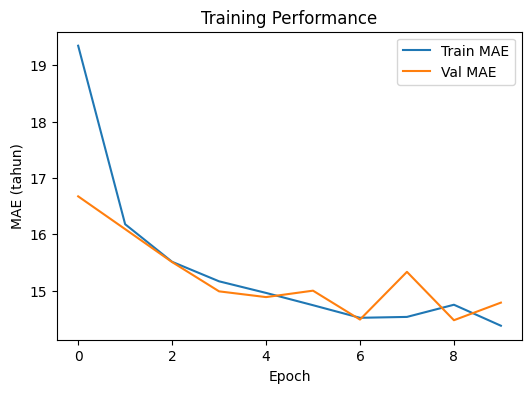

📊 MAE pada data test: 14.79 tahun
✅ Model disimpan sebagai age_model.h5

🧍‍♂️ PREDIKSI UMUR DARI FOTO PRIBADI
📸 Silakan upload 1 atau beberapa foto wajah kamu...


Saving viskom.png to viskom.png


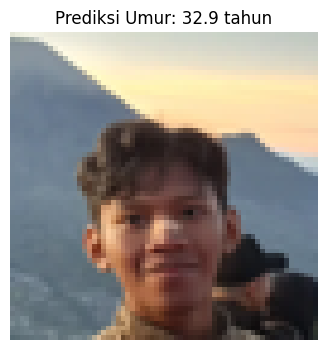

📷 viskom.png: diprediksi berumur 32.9 tahun.


In [4]:
# ========== 1️⃣ IMPORT & SETUP ==========
import os, glob, io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from google.colab import files  # jangan tertimpa!

print("✅ Library berhasil diimpor.")

# ========== 2️⃣ DOWNLOAD DATASET ==========
!kaggle datasets download -d jangedoo/utkface-new -p /content -q
!unzip -qo /content/utkface-new.zip -d /content/utk/

dataset_files = glob.glob("/content/utk/UTKFace/*.jpg")
print(f"Total gambar ditemukan: {len(dataset_files)}")

# ========== 3️⃣ PREPROCESSING ==========
IMG_SIZE = 64

def load_data(files):
    X, y = [], []
    for f in files:
        try:
            age = int(os.path.basename(f).split("_")[0])
            img = Image.open(f).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
            X.append(np.array(img) / 255.0)
            y.append(age)
        except:
            continue
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Ambil sebagian agar cepat
if len(dataset_files) > 0:
    X, y = load_data(dataset_files[:5000])
    print(f"Dataset shape: {X.shape}, Label shape: {y.shape}")

    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ========== 4️⃣ BANGUN MODEL CNN ==========
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(optimizer='adam', loss='mae', metrics=['mae'])
    print("✅ Model CNN siap dilatih.")
    model.summary()

    # ========== 5️⃣ TRAINING ==========
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=64,
        verbose=1
    )

    plt.figure(figsize=(6,4))
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE (tahun)')
    plt.legend()
    plt.title("Training Performance")
    plt.show()

    # ========== 6️⃣ EVALUASI ==========
    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
    print(f"📊 MAE pada data test: {test_mae:.2f} tahun")

    model.save("age_model.h5")
    print("✅ Model disimpan sebagai age_model.h5")

    # ========== 7️⃣ PREDIKSI FOTO PRIBADI ==========
    print("\n" + "="*60)
    print("🧍‍♂️ PREDIKSI UMUR DARI FOTO PRIBADI")
    print("="*60)
    print("📸 Silakan upload 1 atau beberapa foto wajah kamu...")

    uploaded = files.upload()

    def preprocess_image(img_bytes):
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
        img_resized = img.resize((IMG_SIZE, IMG_SIZE))
        img_arr = np.array(img_resized, dtype=np.float32) / 255.0
        return img_resized, tf.expand_dims(img_arr, 0)

    for fname, img_bytes in uploaded.items():
        img_resized, img_tensor = preprocess_image(img_bytes)
        pred_age = model.predict(img_tensor, verbose=0).ravel()[0]

        plt.figure(figsize=(4,4))
        plt.imshow(img_resized)
        plt.title(f"Prediksi Umur: {pred_age:.1f} tahun", fontsize=12)
        plt.axis("off")
        plt.show()

        print(f"📷 {fname}: diprediksi berumur {pred_age:.1f} tahun.")

else:
    print("❌ Tidak ada file gambar yang ditemukan. Pastikan dataset berhasil diunduh dan diekstrak.")


✅ Dataset siap digunakan — 7929 untuk training, 1983 untuk validasi.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 103s 495ms/step - loss: 915.2990 - mae: 22.6014 - val_loss: 488.4622 - val_mae: 16.0623 - learning_rate: 0.0010
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 37s 195ms/step - loss: 439.3324 - mae: 15.4402 - val_loss: 433.9556 - val_mae: 15.3407 - learning_rate: 0.0010
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 37s 196ms/step - loss: 395.2456 - mae: 14.7255 - val_loss: 412.2377 - val_mae: 14.8552 - learning_rate: 0.0010
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 42s 207ms/step - loss: 377.2232 - mae: 14.4625 - val_loss: 396.5452 - val_mae: 14.6122 - learning_rate: 0.0010
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 38s 206ms/step - loss: 363.3114 - mae: 14.1154 - val_loss: 387.5007 - val_mae: 14.7441 - learning_rate: 0.0010
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 41s 207ms/step - loss: 348.5689 - mae: 13.8457 - val_loss: 381.6888 - val_mae: 14.2326 - learning_rate: 0.0010
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 38s 206ms/step - loss: 344.0140 - mae: 13.9077 - val_

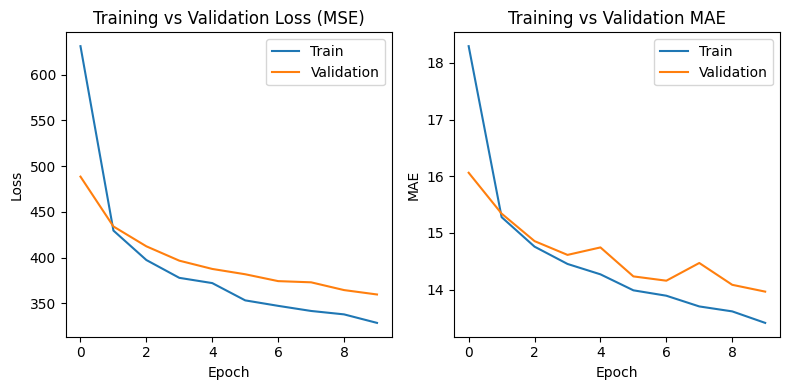

MAE  = 13.96
RMSE = 18.96
R²   = 0.187


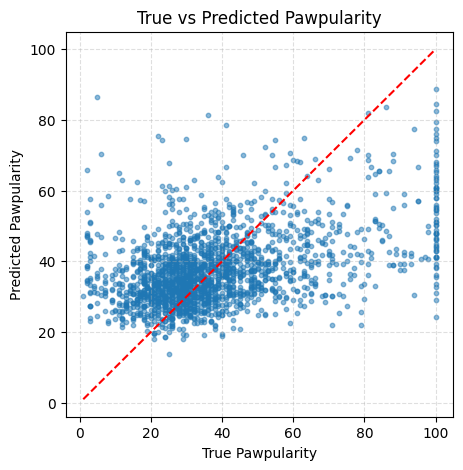

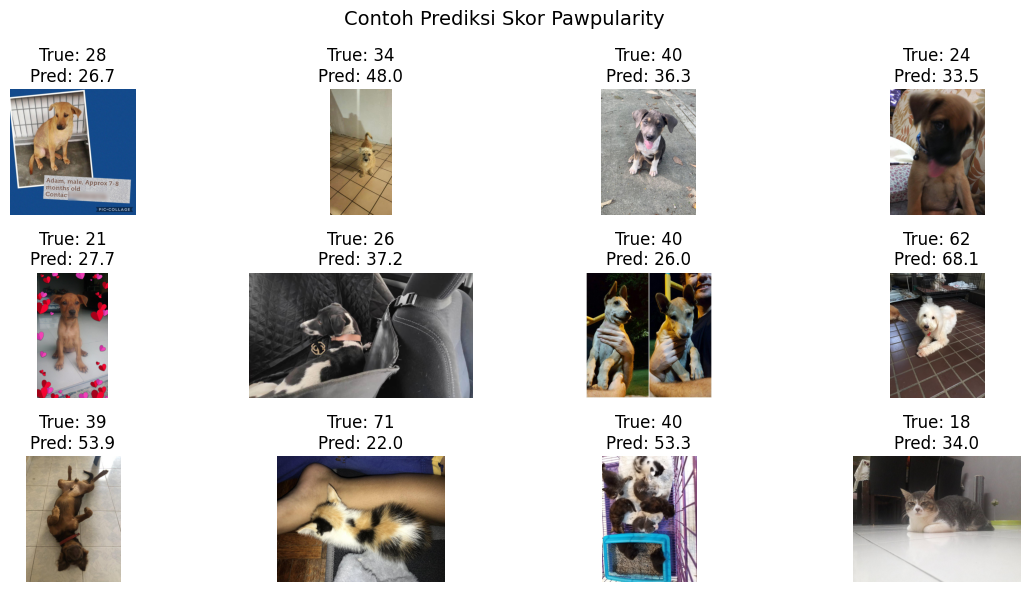

📸 Silakan unggah 1 atau beberapa foto kucing / anjing / hewan peliharaan kamu...


Saving viskom1.jpg to viskom1.jpg


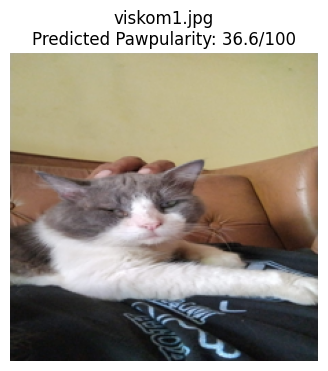

✅ Semua foto pribadi berhasil diprediksi oleh model Pawpularity!


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from math import sqrt
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd  # Import pandas

# ====================================================
# 📂 1️⃣ Persiapan Dataset Pawpularity
# ====================================================

# Load the dataframe
df = pd.read_csv('/content/paw/train.csv')
df['path'] = df['Id'].apply(lambda x: f"/content/paw/train/{x}.jpg")

IMG_SIZE = 224

# Split dataset
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.float32)

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_df['path'], train_df['Pawpularity']))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(4096)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_df['path'], val_df['Pawpularity']))
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"✅ Dataset siap digunakan — {len(train_df)} untuk training, {len(val_df)} untuk validasi.")

# ====================================================
# 🧠 2️⃣ Bangun Model EfficientNetB0
# ====================================================

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)
base.trainable = False  # freeze sementara

inputs = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs * 255.0)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(1)(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ====================================================
# 🏋️ 3️⃣ Training Model
# ====================================================
cb = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)
]

history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=cb, verbose=1)

# ====================================================
# 📈 4️⃣ Visualisasi Proses Training
# ====================================================
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Training vs Validation Loss (MSE)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train')
plt.plot(history.history['val_mae'], label='Validation')
plt.title("Training vs Validation MAE")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.legend()
plt.tight_layout()
plt.show()

# ====================================================
# 🧮 5️⃣ Evaluasi Model
# ====================================================
y_true = val_df['Pawpularity'].values.astype(np.float32)
y_pred = np.concatenate([model.predict(batch[0], verbose=0).ravel() for batch in val_ds])
mae = mean_absolute_error(y_true, y_pred)
rmse = sqrt(np.mean((y_true - y_pred)**2))
r2 = r2_score(y_true, y_pred)
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.3f}")

plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, s=10, alpha=0.5)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='red')
plt.xlabel("True Pawpularity")
plt.ylabel("Predicted Pawpularity")
plt.title("True vs Predicted Pawpularity")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# ====================================================
# 📸 6️⃣ Contoh Prediksi dari Dataset Validasi
# ====================================================
import random
sample_rows = val_df.sample(12, random_state=1)
plt.figure(figsize=(12,6))
for i, row in enumerate(sample_rows.itertuples()):
  img = Image.open(row.path)
  pred = model.predict(tf.expand_dims(load_image(row.path, row.Pawpularity)[0], 0), verbose=0).ravel()[0]
  plt.subplot(3,4,i+1)
  plt.imshow(img)
  plt.title(f"True: {row.Pawpularity}\nPred: {pred:.1f}")
  plt.axis('off')
plt.suptitle("Contoh Prediksi Skor Pawpularity", fontsize=14)
plt.tight_layout()
plt.show()

# ====================================================
# 🧩 7️⃣ Uji Model dengan Foto Pribadi / Hewan Peliharaan
# ====================================================
from google.colab import files
import io

print("📸 Silakan unggah 1 atau beberapa foto kucing / anjing / hewan peliharaan kamu...")
uploaded = files.upload()

def preprocess_image_for_model(path_or_bytes):
    """Preprocess gambar pribadi agar sesuai input model Pawpularity"""
    if isinstance(path_or_bytes, str):  # path file lokal
        img = Image.open(path_or_bytes).convert("RGB")
    else:  # file upload dari Colab (bytes)
        img = Image.open(io.BytesIO(path_or_bytes)).convert("RGB")

    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img, dtype=np.float32) / 255.0
    img_tensor = np.expand_dims(img, axis=0)
    return img_tensor

# 🔹 Prediksi Pawpularity dari gambar pribadi
for fname, file_bytes in uploaded.items():
    img_tensor = preprocess_image_for_model(file_bytes)
    pred = model.predict(img_tensor, verbose=0).ravel()[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(np.squeeze(img_tensor))
    plt.axis('off')
    plt.title(f"{fname}\nPredicted Pawpularity: {pred:.1f}/100", fontsize=12)
    plt.show()

print("✅ Semua foto pribadi berhasil diprediksi oleh model Pawpularity!")